# Dataset Description

This notebook contains the project section requested for the final ML presentation.


# Heavy Vehicle Failure Prediction Through Intelligent Sensor Data

## Complete Machine Learning Project Notebook

**Task:** Binary classification of APS-related failure in Scania heavy vehicles  
**Target:** `class` (`neg` = no APS-related failure, `pos` = APS-related failure)

This notebook contains the implementation, preprocessing, EDA, model training, tuning, evaluation, comparison, and final prediction demonstration required for the project review. Execute all cells from top to bottom before submission so the outputs and figures are visible.

The data contains 76,000 records, 170 sensor features, and a highly imbalanced target. Because missing a real failure can be costly, recall and F1-score are considered together with accuracy and ROC-AUC.


## 1. Import Libraries

The pipeline objects used later ensure that imputation and scaling are learned only from the training portion of the data. This prevents test-data leakage.


In [2]:

import os
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 2. Load the Dataset

The original combined CSV is used because it contains both sensor values and the target label. The value `na` is converted to a real missing value while loading.


In [3]:
candidate_paths = [
    Path("D:\\ML\\HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR\\dataset\\APS_Scania_Complete_Dataset.csv"),
    Path("APS_Scania_Complete_Dataset.csv"),
    Path("/content/APS_Scania_Complete_Dataset.csv"),
    Path("/content/HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR/dataset/APS_Scania_Complete_Dataset.csv")
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place APS_Scania_Complete_Dataset.csv in the notebook folder or update DATA_PATH.")

df = pd.read_csv(DATA_PATH, na_values=["na"])
print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Dataset path: D:\ML\HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR\dataset\APS_Scania_Complete_Dataset.csv
Dataset shape: (76000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,1766008.0,1132040.0,0.0,0.0,0.0,0.0,1012.0,268.0,0.0,0.0,0.0,0.0,0.0,469014.0,4239660.0,703300.0,755876.0,0.0,5374.0,2108.0,4114.0,12348.0,615248.0,5526276.0,2378.0,4.0,0.0,0.0,2328746.0,1022304.0,415432.0,287230.0,310246.0,681504.0,1118814.0,3574.0,0.0,0.0,6700214.0,0.0,10.0,108.0,50.0,2551696.0,97518.0,947550.0,799478.0,330760.0,353400.0,299160.0,305200.0,283680.0,NaN,NaN,NaN,178540.0,76698.08,6700214.0,6700214.0,6599892.0,43566.0,68656.0,54064.0,638360.0,6167850.0,1209600.0,246244.0,2.0,96.0,0.0,5245752.00,0.0,916567.68,6.0,1924.0,0.0,0.0,0.0,118196.0,1309472.0,3247182.0,1381362.0,98822.0,11208.0,1608.0,220.0,240.0,6700214.0,NaN,10476.0,1226.0,267998.0,521832.0,428776.0,4015854.0,895240.0,26330.0,118.0,0.0,532.0,734.0,4122704.0,51288.0,0.0,532572.0,0.0,18.0,5330690.0,4732.0,1126.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62282.0,85908.0,32790.0,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,1084598.0,338544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71510.0,772720.0,1996924.0,99560.0,0.0,7336.0,7808.0,13776.0,13086.0,1010074.0,1873902.0,14726.0,6.0,0.0,0.0,1378576.0,447166.0,199512.0,154298.0,137280.0,138668.0,165908.0,229652.0,87082.0,4708.0,3646660.0,86.0,454.0,364.0,350.0,1393352.0,49028.0,688314.0,392208.0,341420.0,359780.0,366560.0,NaN,NaN,NaN,NaN,NaN,6700.0,33057.51,3646660.0,3646660.0,3582034.0,17733.0,260120.0,115626.0,6900.0,2942850.0,1209600.0,0.0,NaN,NaN,NaN,2291079.36,0.0,643536.96,0.0,0.0,0.0,0.0,38.0,98644.0,1179502.0,1286736.0,336388.0,36294.0,5192.0,56.0,NaN,0.0,3646660.0,NaN,6160.0,796.0,164860.0,350066.0,272956.0,1837600.0,301242.0,9148.0,22.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3312.0,522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33736.0,36946.0,5936.0,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,300796.0,153698.0,0.0,0.0,0.0,0.0,358.0,110.0,0.0,0.0,0.0,0.0,0.0,0.0,870456.0,239798.0,1450312.0,0.0,1620.0,1156.0,1228.0,34250.0,1811606.0,710672.0,34.0,0.0,0.0,0.0,790690.0,672026.0,332340.0,254892.0,189596.0,135758.0,103552.0,81666.0,46.0,0.0,2673338.0,128.0,202.0,576.0,4.0,1234132.0,28804.0,160176.0,139730.0,137160.0,13064

## 3. Dataset Description

The dataset contains anonymized sensor and operational measurements collected from Scania heavy trucks. The target indicates whether a failure is related to the Air Pressure System.


In [4]:
print("Records:", df.shape[0])
print("Columns:", df.shape[1])
print("Sensor features:", df.shape[1] - 1)
print("Target variable: class")

print("\nData types:")
display(df.dtypes.value_counts())

print("\nTarget distribution:")
display(df["class"].value_counts(dropna=False).rename_axis("class").to_frame("count"))

print("\nTarget percentage:")
display((df["class"].value_counts(normalize=True) * 100).round(2).rename("percentage").to_frame())


Records: 76000
Columns: 171
Sensor features: 170
Target variable: class

Data types:


float64    169
str          1
int64        1
Name: count, dtype: int64


Target distribution:


,count
class,
neg,74625
pos,1375



Target percentage:


,percentage
class,
neg,98.19
pos,1.81


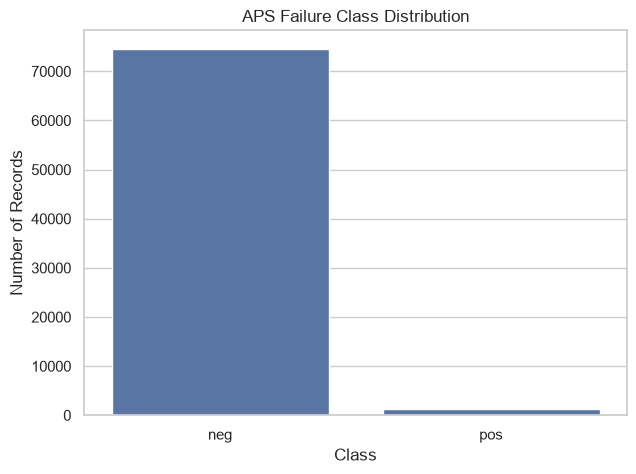

In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="class", order=["neg", "pos"])
plt.title("APS Failure Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.show()


### Dataset Observation

The negative class is much larger than the positive class. This class imbalance means that a model could obtain high accuracy by mostly predicting no failure, while still missing many actual failures. Recall, F1-score, ROC-AUC, and the confusion matrix are therefore important.
